In [13]:
import json

#file_path = "./benchmark_results/error finder gemini/corrected-gemini-2.5-flash-preview-05-20.json"
#file_path = "./benchmark_results/error finder gemini/corrected-gemini-2.5-pro-preview-06-05-low.json"
#file_path = "./benchmark_results/error finder gemini/corrected-gemini-2.5-pro-preview-06-05-medium.json"
#file_path = "./benchmark_results/error finder gemini/gemini-2.5-pro-preview-06-05-high.json"

#file_path = "./benchmark_results/error finder gemini/gemini-2.5-flash-preview-05-20 avec prompt v2.json"
#file_path = "./benchmark_results/error finder gemini/gemini-2.5-flash-preview-05-20 avec prompt v3.json"
file_path = "./benchmark_results/error finder gemini/gemini-2.5-flash-preview-05-20 avec prompt v3 + correc.json"

with open(file_path, 'r', encoding='utf-8') as f:
	results_pre = json.load(f)

In [49]:
categ = "alLin"
student = "9"
exercise = "1"

ex = results_pre[categ][student][exercise]

In [50]:
print("==========================================")
print(ex["errors"])
print("==========================================")
print(ex["response"])
print("==========================================")

{'1': {'line': 71, 'description': 'erreur de calcul, (\\Gamma = (x-2)^2+(y-0)^2 = \\sqrt{10}) devrait être égal à (\\Gamma = (x-2)^2+(y-0)^2 = (\\sqrt{10})^2)'}, '2': {'line': 86, 'description': 'mauvaise réponse'}}
```json
{
"line":"e \\Rightarrow y = x-2",
"number":"25",
"desc":"The student incorrectly determined the equation of line $e$. Line $e$ is orthogonal to line $d$. The direction vector of $d$ is $(3,1)$, so its slope is $1/3$. Therefore, the slope of $e$ should be $-1/(1/3) = -3$, not $1$.",
"correction":"The line $d$ has a direction vector $\\vec{AB} = \\begin{pmatrix} 3 \\\\ 1 \\end{pmatrix}$, so its slope is $m_d = \\frac{1}{3}$.\nThe line $e$ is orthogonal to $d$, so its slope $m_e$ must satisfy $m_e \\cdot m_d = -1$, which gives $m_e = -3$.\nThe line $e$ passes through the point $(2, 0)$. Its equation is therefore $y - 0 = -3(x - 2)$, which simplifies to $y = -3x + 6$.\n\nThe equation of the circle $\\Gamma$ with center $(2, 0)$ and radius $\\sqrt{10}$ is $(x - 2)^2 + (

In [14]:
def index2(list, item):
	try:
		pos = list.index(item)
		return pos
	except:
		return 0

In [15]:
import re

def resp_to_dict(resp):
	lines = resp.split("\n")
	#print(lines)
	lineTitle = index2(lines, "## Line with the first mistake:")
	lineNumTitle = index2(lines, "## Number of the line:") 
	descTitle = index2(lines, "## Description of the error:") 
	
	

	if lineTitle < lineNumTitle < descTitle:
		line = lines[lineTitle+1:lineNumTitle]
		num = lines[lineNumTitle+1:descTitle]
		desc = lines[descTitle+1:]

		merLine = ""
		numLine = ""
		descLine = ""

		for i in line:
			merLine += i
		for i in num:
			numLine += i
		for i in desc:
			descLine += i


		return {"line": merLine, "number": numLine, "desc": descLine}
	else:
		print("yapatou")
		return {}


In [16]:
import json

def resp2_to_dict(resp):
	resp = resp.replace('\\', "\\\\")
	tab = json.loads(resp[8:-4])
	return(tab)

In [17]:
suc = 0
tot = 0

for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]
			if current_result != {}:
				tot += 1
				try:
					resp = current_result["response"]

					#resp = resp_to_dict(resp)
					resp = resp2_to_dict(resp)
					
					errors = current_result["errors"]

					error_line = resp["number"]
					#real_line = errors['1']["line"]

					suc += 1
				except Exception as e:
					print(e)
					print(resp)
					suc += 0

print(suc, " / ", tot)


Invalid control character at: line 5 column 75 (char 385)
```json
{
"line":"\[ 7 \cdot \sum_{k=1}^{6} (10^{-k}) \rightarrow \sum_{k=0}^{n} (x^k) = \frac{1-x^{n-1}}{1-x} \]",
"number":"7",
"desc":"The formula for the sum of a geometric series is incorrect. For a sum starting from k=0 up to n, the correct formula is $\\sum_{k=0}^{n} x^k = \\frac{1-x^{n+1}}{1-x}$.",
"correction":"The sum $\\sum_{k=1}^{6} (10^{-k})$ is a geometric series.
The first term is $a = 10^{-1} = 0.1$.
The common ratio is $r = 10^{-1} = 0.1$.
The number of terms is $N = 6$.
The formula for the sum of a geometric series is $S_N = a \\frac{1-r^N}{1-r}$.
Therefore, the sum is:
\\[ 7 \\cdot \\left( 0.1 \\frac{1-(0.1)^6}{1-0.1} \\right) \\]
\\[ = 7 \\cdot \\left( 0.1 \\frac{1-0.000001}{0.9} \\right) \\]
\\[ = 7 \\cdot \\left( 0.1 \\frac{0.999999}{0.9} \\right) \\]
\\[ = 7 \\cdot \\left( \\frac{0.0999999}{0.9} \\right) \\]
\\[ = 7 \\cdot 0.111111 \\]
\\[ = 0.777777 \\]"
}
```
120  /  121


In [18]:
VP = 0 # bon positif: il a dit y avait pas d'erreur et avait raison
VN = 0 # bon négatif: il a dit y avait une erreur et avait raison
FP = 0 # faux positif: il a dit y avait pas d'erreur mais y avait une erreur
FN = 0 # faux négatif: il a dit y avait une erreur mais y avait pas d'erreur


for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]
			if current_result != {}:
				tot += 1
				resp = ""
				try:
					resp = current_result["response"]
					#resp = resp_to_dict(resp)
					resp = resp2_to_dict(resp)
					errors = current_result["errors"]

					if resp["number"] == "-1": # si le LLM a dit y avait pas d'erreur
						if errors == {}: # et que y avait une erreur
							VP += 1
							current_result["resultat"] = "VP"
						else:  # et que y avait une erreur
							FP += 1
							current_result["resultat"] = "FP"
					else: # si le LLM a dit y avait une erreur
						if errors == {}: # et que y avait pas d'erreur
							FN += 1
							current_result["resultat"] = "FN"
						else: # et que y avait une erreur
							VN += 1 
							current_result["resultat"] = "VN"
					#error_line = resp["line_num"]
					#real_line = errors['1']["line"]

					suc += 1
				except:
					print(resp)
					suc += 0

print("vrai positifs: ", VP)
print("vrai négatifs: ", VN)
print("faux positifs: ", FP)
print("faux négatifs: ", FN)

```json
{
"line":"\[ 7 \cdot \sum_{k=1}^{6} (10^{-k}) \rightarrow \sum_{k=0}^{n} (x^k) = \frac{1-x^{n-1}}{1-x} \]",
"number":"7",
"desc":"The formula for the sum of a geometric series is incorrect. For a sum starting from k=0 up to n, the correct formula is $\\sum_{k=0}^{n} x^k = \\frac{1-x^{n+1}}{1-x}$.",
"correction":"The sum $\\sum_{k=1}^{6} (10^{-k})$ is a geometric series.
The first term is $a = 10^{-1} = 0.1$.
The common ratio is $r = 10^{-1} = 0.1$.
The number of terms is $N = 6$.
The formula for the sum of a geometric series is $S_N = a \\frac{1-r^N}{1-r}$.
Therefore, the sum is:
\\[ 7 \\cdot \\left( 0.1 \\frac{1-(0.1)^6}{1-0.1} \\right) \\]
\\[ = 7 \\cdot \\left( 0.1 \\frac{1-0.000001}{0.9} \\right) \\]
\\[ = 7 \\cdot \\left( 0.1 \\frac{0.999999}{0.9} \\right) \\]
\\[ = 7 \\cdot \\left( \\frac{0.0999999}{0.9} \\right) \\]
\\[ = 7 \\cdot 0.111111 \\]
\\[ = 0.777777 \\]"
}
```
vrai positifs:  11
vrai négatifs:  98
faux positifs:  3
faux négatifs:  8


In [19]:
def inverser_structure(donnees):
    donnees_inverses = {}

    for categorie, eleves in donnees.items():
        exercices = {}

        for eleve_id, exercices_dict in eleves.items():
            for exercice_id, variables in exercices_dict.items():
                if exercice_id not in exercices:
                    exercices[exercice_id] = {}
                exercices[exercice_id][eleve_id] = variables

        donnees_inverses[categorie] = exercices

    return donnees_inverses


In [20]:
yay = inverser_structure(results_pre)

In [45]:
VP = 0 # bon positif: il a dit y avait pas d'erreur et avait raison
VN = 0 # bon négatif: il a dit y avait une erreur et avait raison
FP = 0 # faux positif: il a dit y avait pas d'erreur mais y avait une erreur
FN = 0 # faux négatif: il a dit y avait une erreur mais y avait pas d'erreur

categ = "alLin"
exercise = "10"

for student in yay[categ][exercise]:
	try:
		current_result = yay[categ][exercise][student]
		res = current_result["resultat"]
	
		match res:
			case "VP":
				VP += 1
			case "VN":
				VN += 1
			case "FP":
				FP += 1
				print("======================================")
				print(student, ", ",current_result["resultat"])
				print("======================================")
				print(current_result["errors"])
				print("======================================")
				print(current_result["response"])
				print("======================================")
			case "FN":
				FN += 1
				print("======================================")
				print(student, ", ",current_result["resultat"])
				print("======================================")
				print(current_result["errors"])
				print("======================================")
				print(current_result["response"])
				print("======================================")
	except:
		print("yapa", current_result)

print("vrai positifs: ", VP)
print("vrai négatifs: ", VN)
print("faux positifs: ", FP)
print("faux négatifs: ", FN)

5 ,  FP
{'1': {'line': 48, 'description': 'Pas de réponse écrite a la question'}}
```json
{
"line":"-",
"number":"-1",
"desc":"-",
"correction":"-"
}
```
vrai positifs:  0
vrai négatifs:  2
faux positifs:  1
faux négatifs:  0


In [22]:
categ = "analyse"
exercise = "3"
student = "2"

try:
	current_result = yay[categ][exercise][student]
	res = current_result["resultat"]

	match res:
		case "VP":
			print("circulez y a rien a voir")
		case "VN":
			print("======================================")
			print(categ, ":", student, ":", exercise, ", ",current_result["resultat"])
			print("======================================")
			print(current_result["errors"])
			print("======================================")
			print(current_result["response"])
			print("======================================")
		case "FP":
			print("ERREUR")
		case "FN":
			print("ERREUR")

except:
	print("y a eu un soucis")

analyse : 2 : 3 ,  VN
{'1': {'line': 11, 'description': 'erreur de calcul'}}
```json
{
"line":"= 7 \\frac{1}{\\frac{10^7-1}{10-1}} \\quad + 1",
"number":"11",
"desc":"Incorrect application of the geometric series sum formula. The series is a sum of powers of 1/10, not 10. An extraneous '+1' is also added.",
"correction":"= 7 \\left( 10^{-1} + 10^{-2} + 10^{-3} + 10^{-4} + 10^{-5} + 10^{-6} \\right)\n\\]\n\\[\n= 7 \\left( 0.1 + 0.01 + 0.001 + 0.0001 + 0.00001 + 0.000001 \\right)\n\\]\n\\[\n= 7 \\left( 0.111111 \\right) = 0.777777\n\\]\n\\[\n\\text{b) } 5 + 9 + 13 + 17 + \\dots + 105\n\\]\n\\[\n\\text{This is an arithmetic progression with first term } a_1 = 5 \\text{ and common difference } d = 4.\n\\]\n\\[\n\\text{To find the number of terms, we use the formula } a_n = a_1 + (n-1)d.\n\\]\n\\[\n105 = 5 + (n-1)4\n\\]\n\\[\n100 = (n-1)4\n\\]\n\\[\n25 = n-1\n\\]\n\\[\nn = 26 \\text{ terms.}\n\\]\n\\[\n\\text{The sum of an arithmetic series is } S_n = \\frac{n}{2}(a_1 + a_n).\n\\]\n\\[\nS_{

In [23]:
diff_annonce = []
score_annonce = []
score_reel = []

n = 0

failed = 0

for categ in results_pre:
	for student in results_pre[categ]:
		for exercise in results_pre[categ][student]:
			current_result = results_pre[categ][student][exercise]

			try:
				# error line according to 
				resp = current_result["response"]
				resp = resp2_to_dict(resp)
				line = resp["line"]
				line = line.replace("\\\\", "\\")
				error_line = resp["number"]

				real_error_line = current_result["errors"]["1"]["line"]

				student_res = current_result["student"].split("\n")

				line_pos = student_res.index(line)
				current_result["error_line_diff"] = int(error_line) - line_pos

				diff_annonce.append(int(error_line) - line_pos)
				score_annonce.append(real_error_line- int(error_line))
				score_reel.append(real_error_line - line_pos)

				if abs(real_error_line - line_pos) > 30:
					print(categ, student, exercise)

				n += 1
				# print("lines (LLM annoncée, LLM réelle, réponse): ")
				# print(error_line)
				# print(line_pos)
				# print(real_error_line)

			except:
				# try:
				# 	print("==============================================")
				# 	print("line (", error_line, "): ", line)
				# 	print("==============================================")
				# 	print("student: ", current_result["student"])
				# 	print("==============================================")
				# except:
				# 	print("damned")
				current_result["error_line_diff"] = 1000
				failed += 1


			

alLin 9 1


In [24]:
failed

53

In [25]:
import numpy as np

print("=========================================")
print("sample:")
print("number that passed: ", n)
print("=========================================")
print("difference absolue entre la ligne annoncée et la ligne pointée: ")
print(np.mean(np.abs(diff_annonce)))
print(np.median(np.abs(diff_annonce)))
print("=========================================")
print("difference absolue entre la ligne d'erreur réelle et la ligne annoncée: ")
print(np.mean(np.abs(score_annonce)))
print(np.median(np.abs(score_annonce)))
print("=========================================")
print("difference absolue entre la ligne d'erreur réelle et la ligne pointée: ")
print(np.mean(np.abs(score_reel)))
print(np.median(np.abs(score_reel)))
print("=========================================")



sample:
number that passed:  86
difference absolue entre la ligne annoncée et la ligne pointée: 
1.8837209302325582
1.0
difference absolue entre la ligne d'erreur réelle et la ligne annoncée: 
3.1627906976744184
2.0
difference absolue entre la ligne d'erreur réelle et la ligne pointée: 
2.511627906976744
1.0


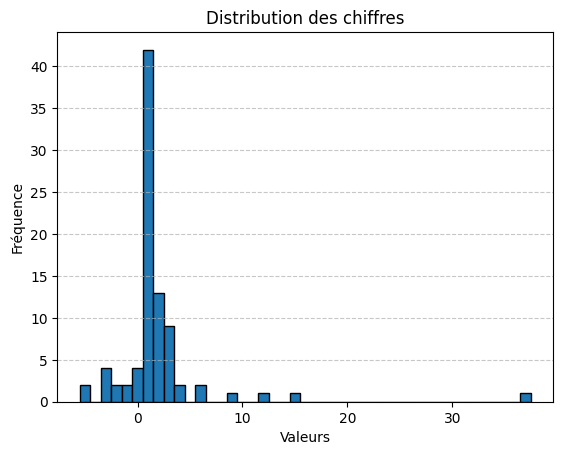

In [48]:
import matplotlib.pyplot as plt

# Exemple de liste d'entiers
liste_de_chiffres = score_reel

# Création de l'histogramme
plt.hist(liste_de_chiffres, bins=range(min(liste_de_chiffres), max(liste_de_chiffres) + 2), align='left', edgecolor='black')

# Ajout des titres et labels
plt.title("Distribution des chiffres")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")

# Affichage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
